Files in directory: ['000007637-AbsorptionImageExpFrag.h5', '000007633-AbsorptionImageExpFrag.h5', '000007629-AbsorptionImageExpFrag.h5', '000007634-AbsorptionImageExpFrag.h5', '000007625-AbsorptionImageExpFrag.h5', '000007635-AbsorptionImageExpFrag.h5', '000007636-AbsorptionImageExpFrag.h5', '000007628-AbsorptionImageExpFrag.h5', '000007640-AbsorptionImageExpFrag.h5', '000007627-AbsorptionImageExpFrag.h5', '000007632-AbsorptionImageExpFrag.h5', '000007626-AbsorptionImageExpFrag.h5', '000007638-AbsorptionImageExpFrag.h5', '000007630-AbsorptionImageExpFrag.h5', '000007639-AbsorptionImageExpFrag.h5', '000007631-AbsorptionImageExpFrag.h5']
File 1: ../results/2025-07-21/21/000007625-AbsorptionImageExpFrag.h5
File 2: ../results/2025-07-21/21/000007626-AbsorptionImageExpFrag.h5
File 3: ../results/2025-07-21/21/000007627-AbsorptionImageExpFrag.h5
File 4: ../results/2025-07-21/21/000007628-AbsorptionImageExpFrag.h5
File 5: ../results/2025-07-21/21/000007629-AbsorptionImageExpFrag.h5
File 6: ..

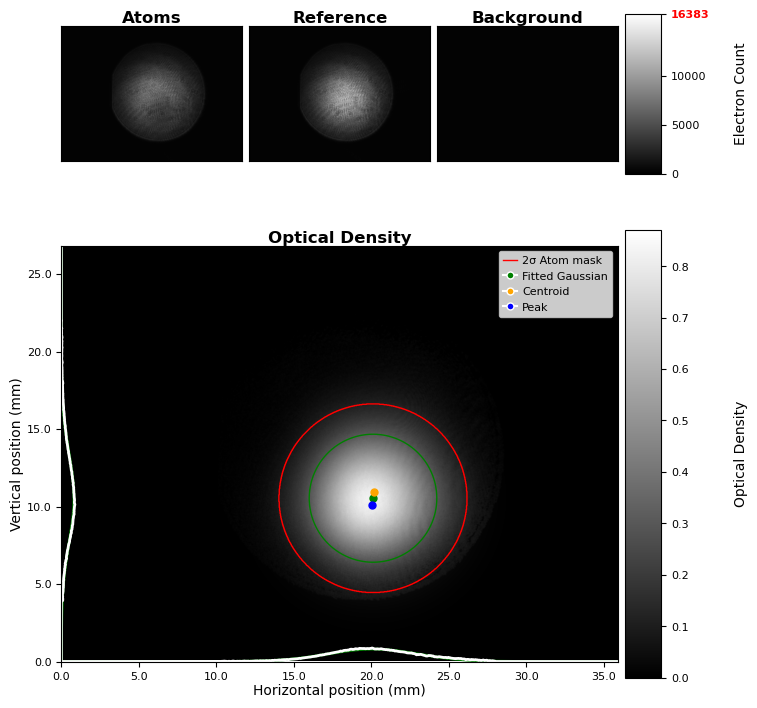

Number of files in the directory: 16


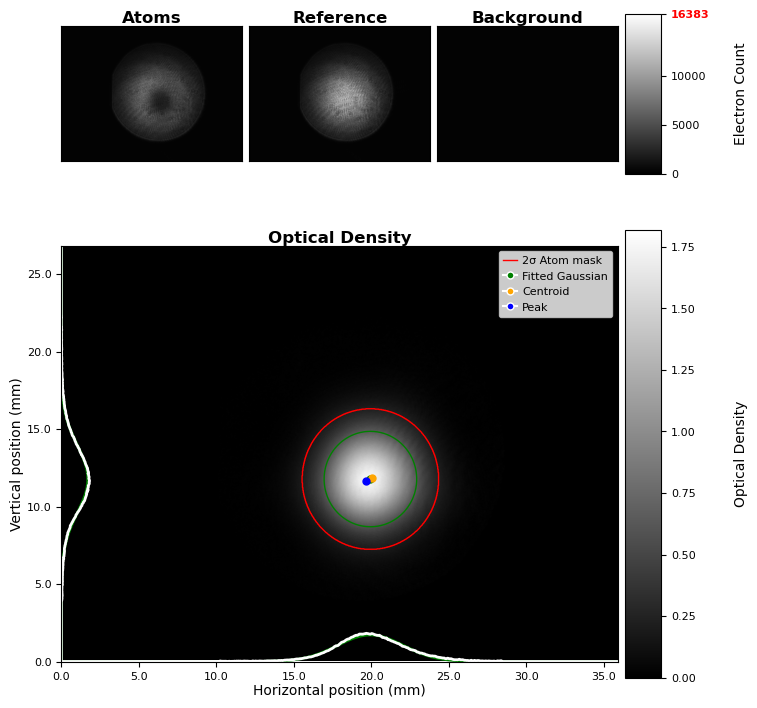

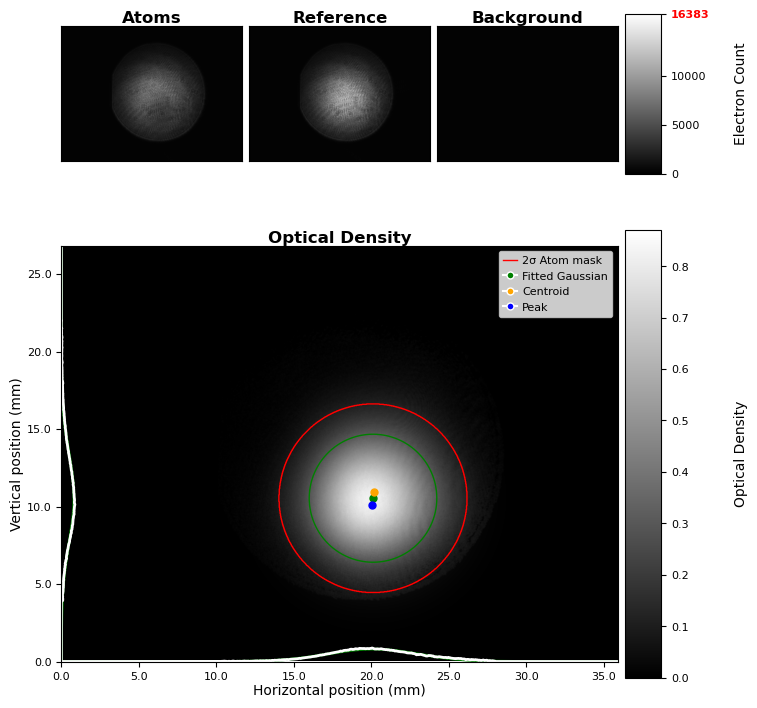

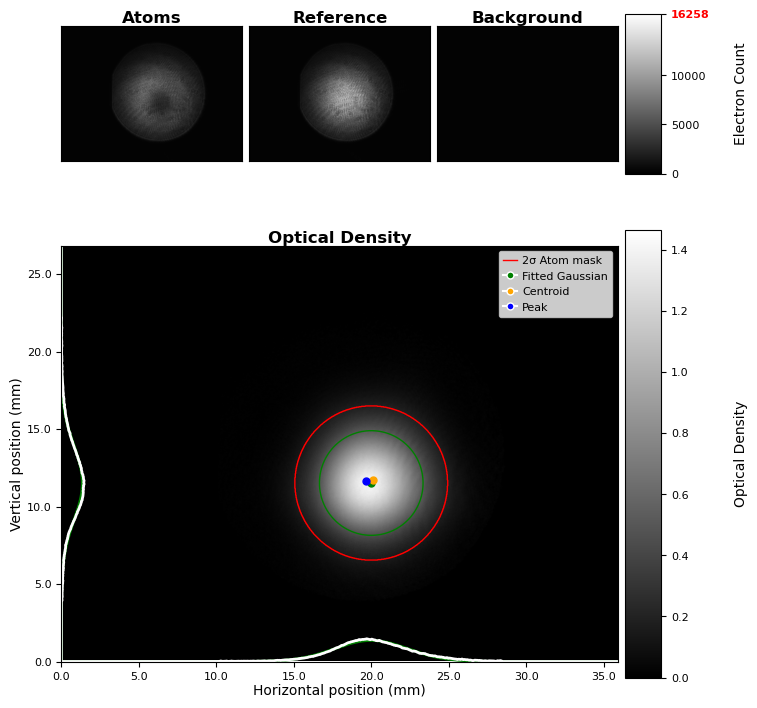

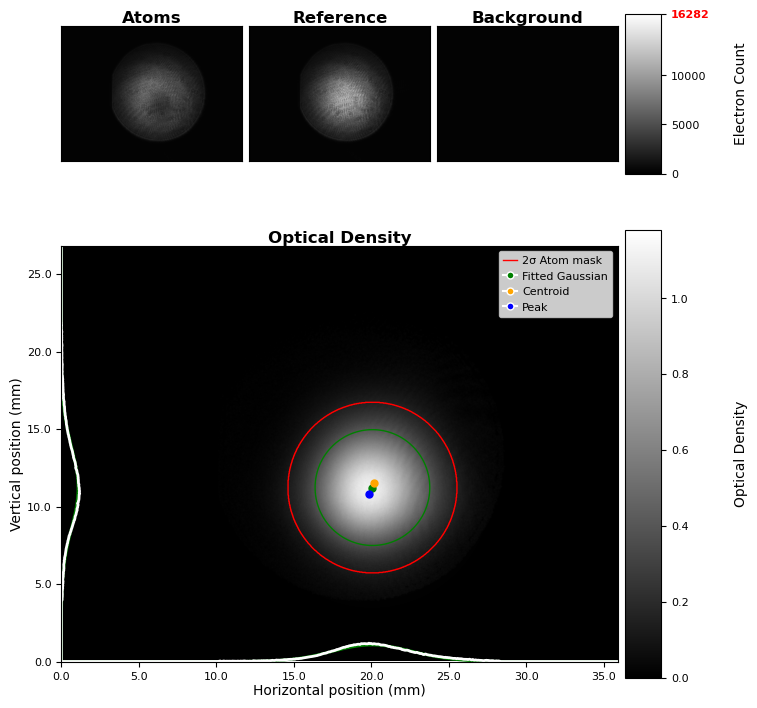

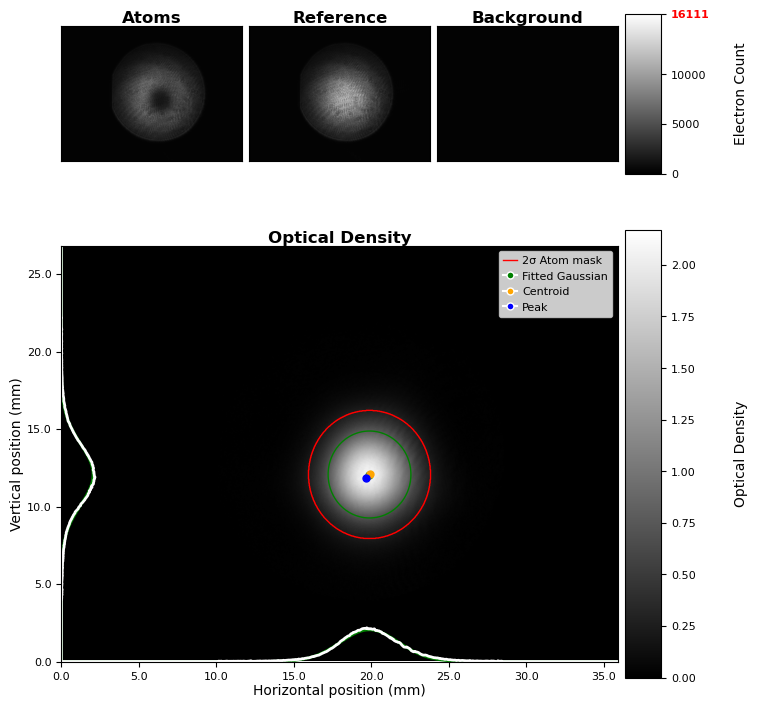

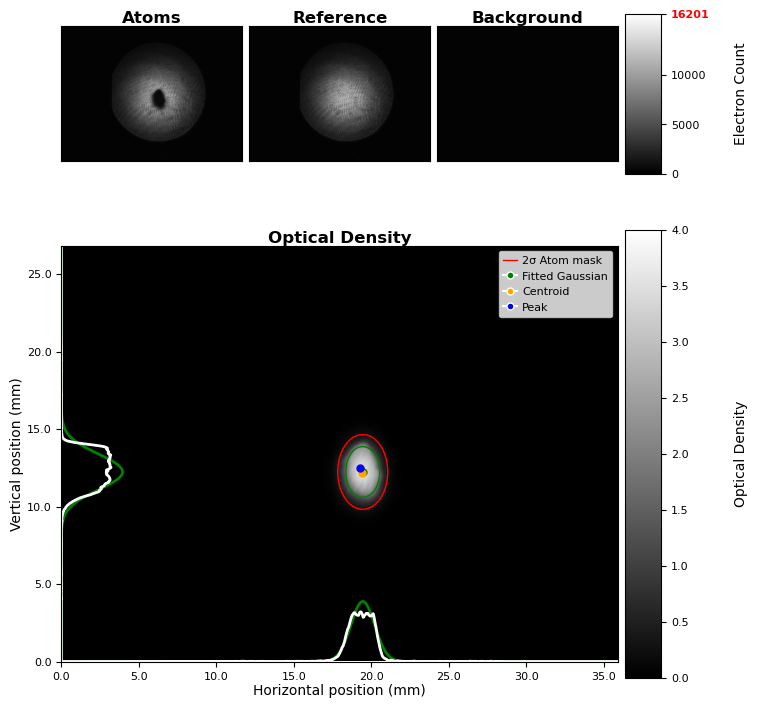

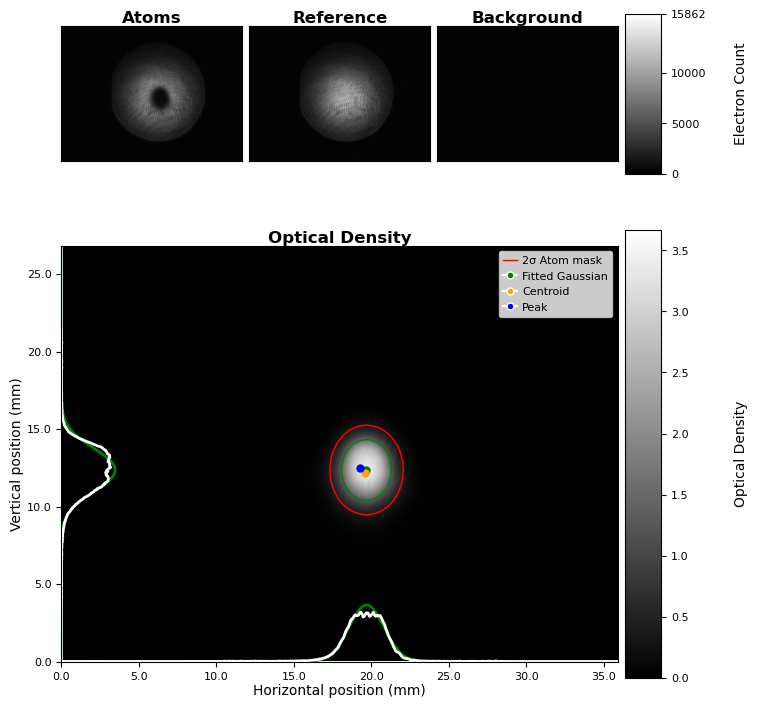

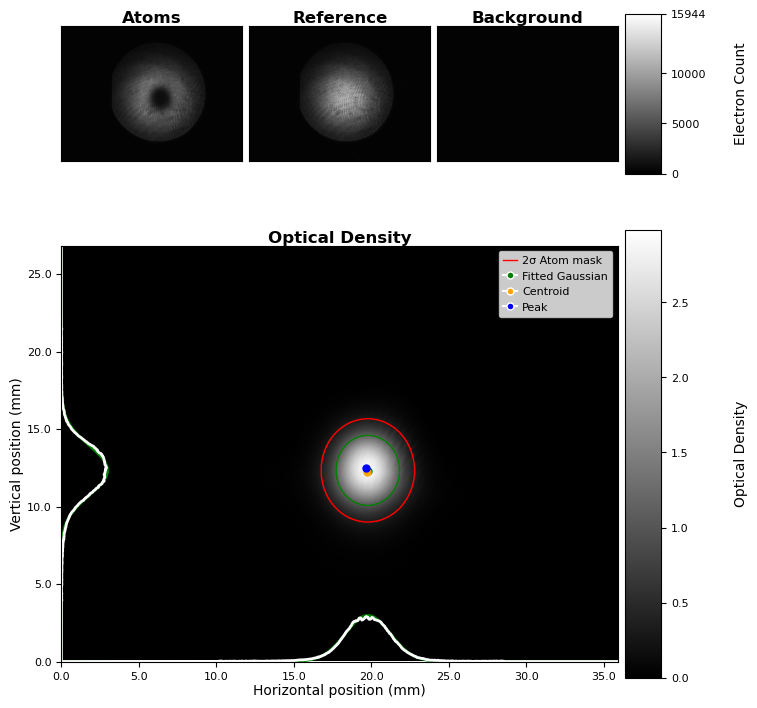

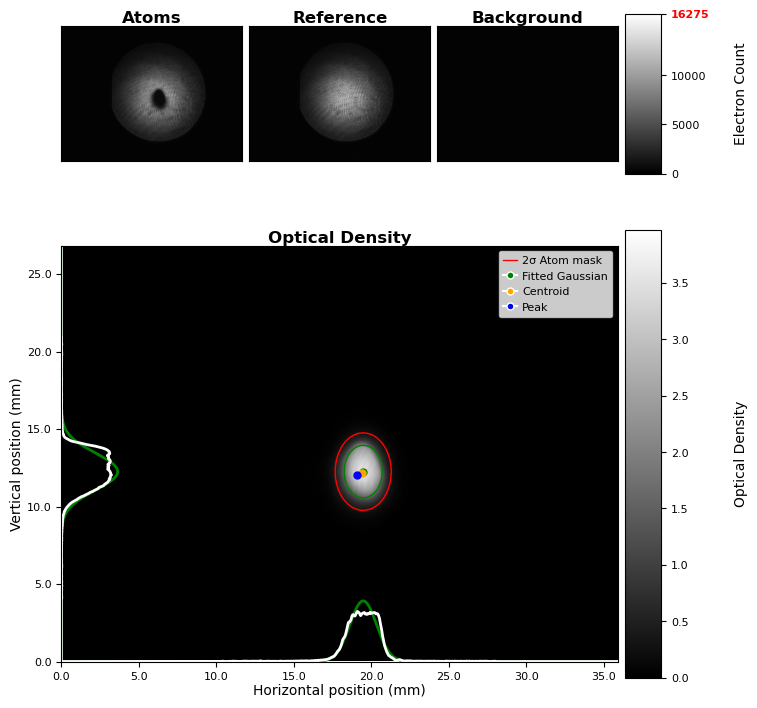

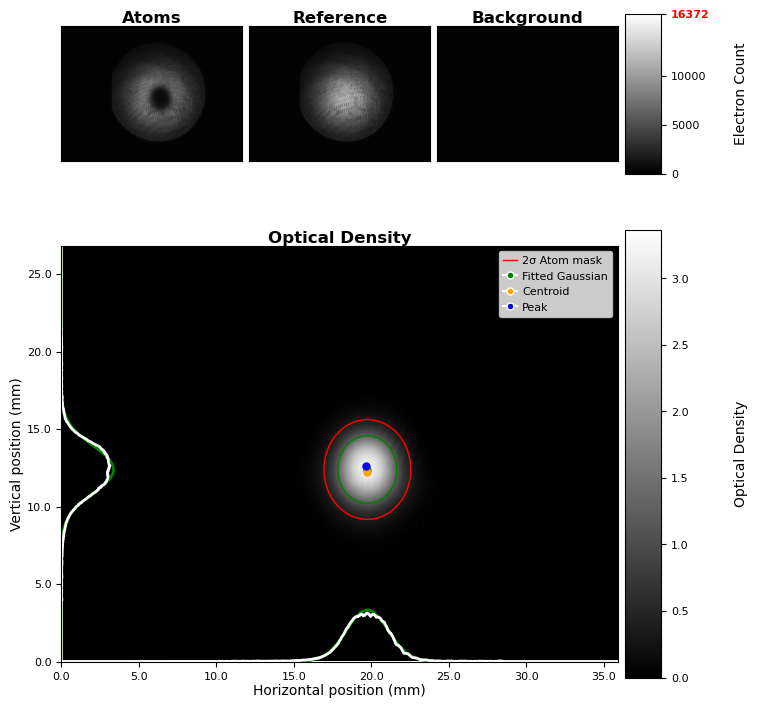

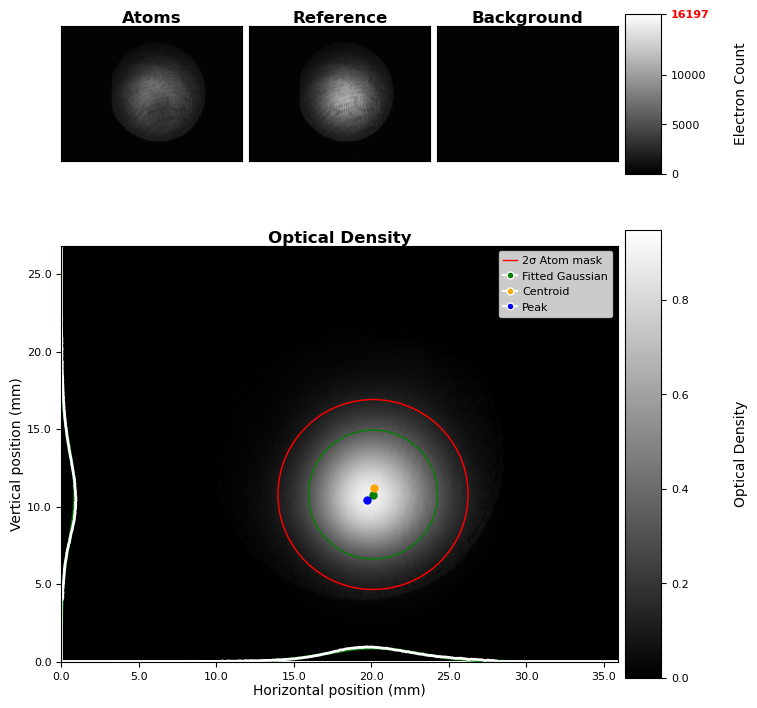

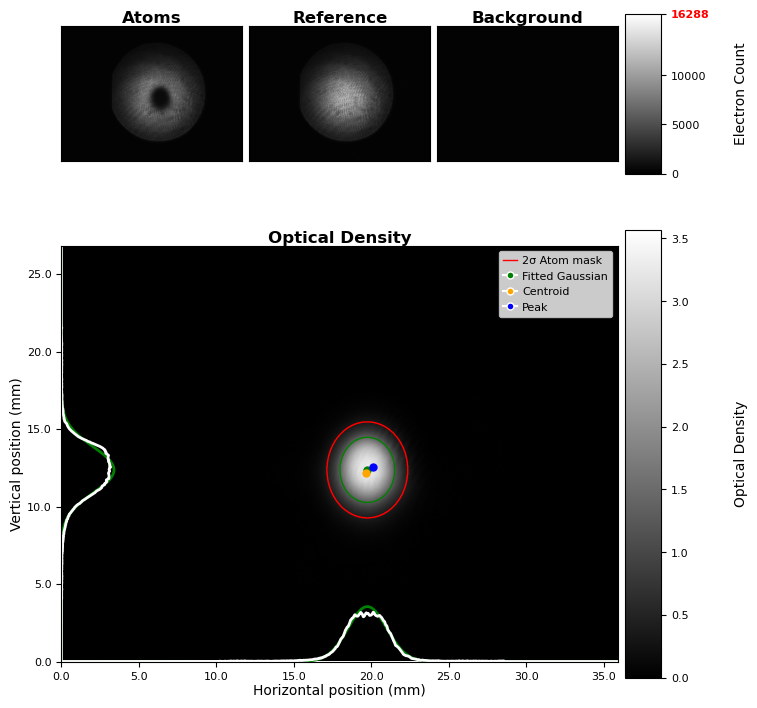

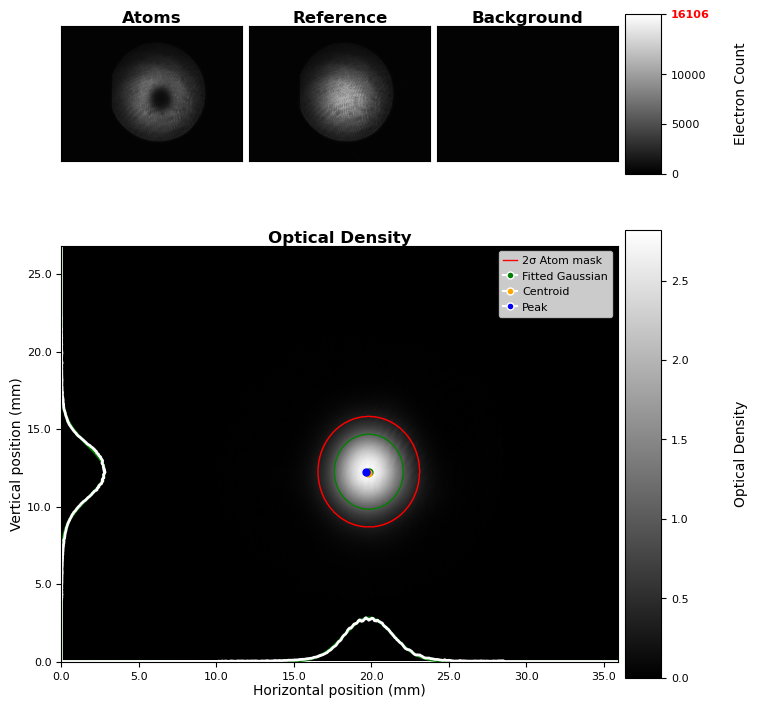

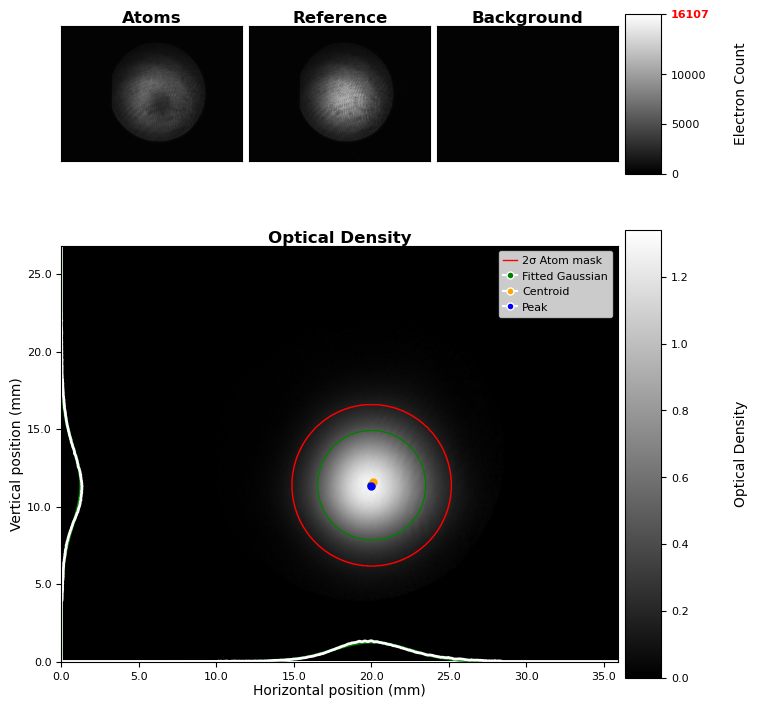

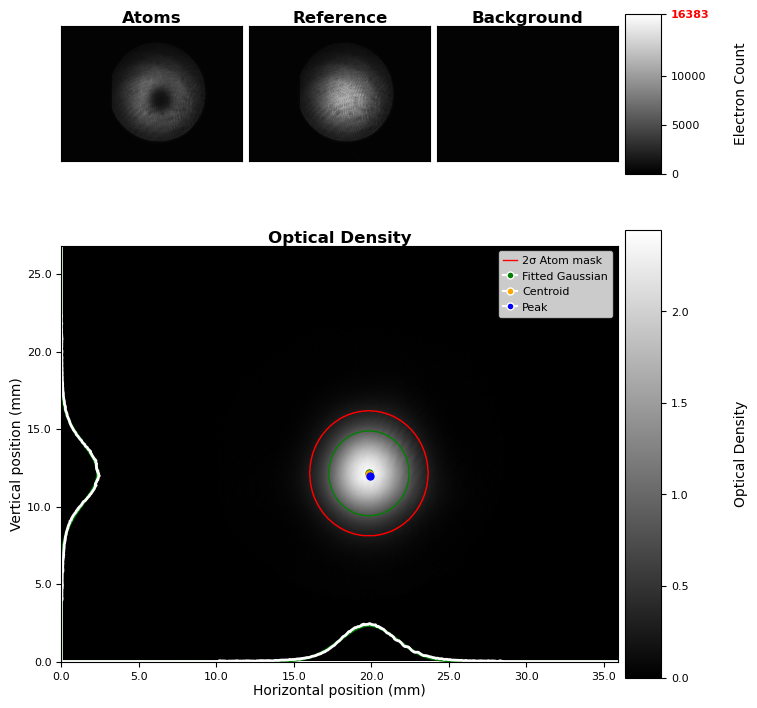

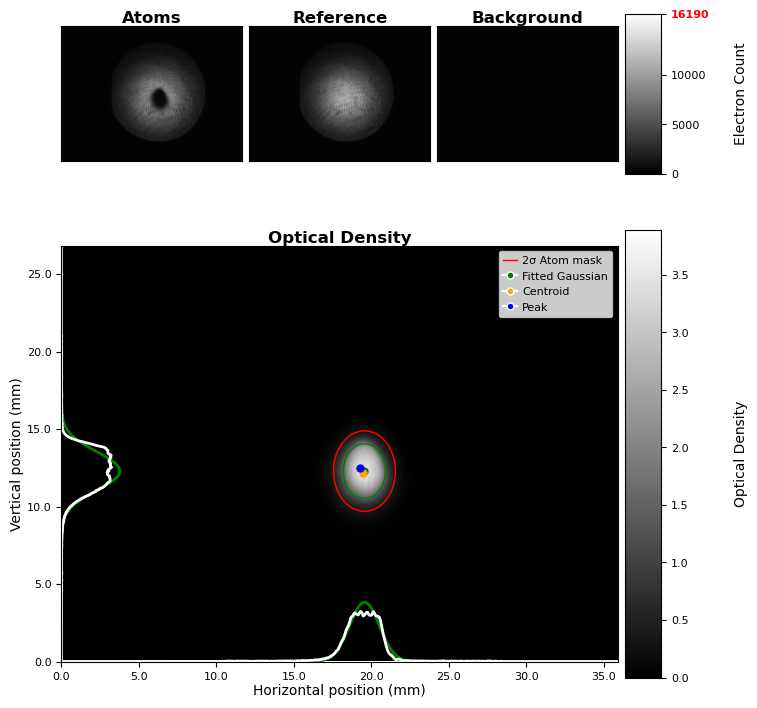

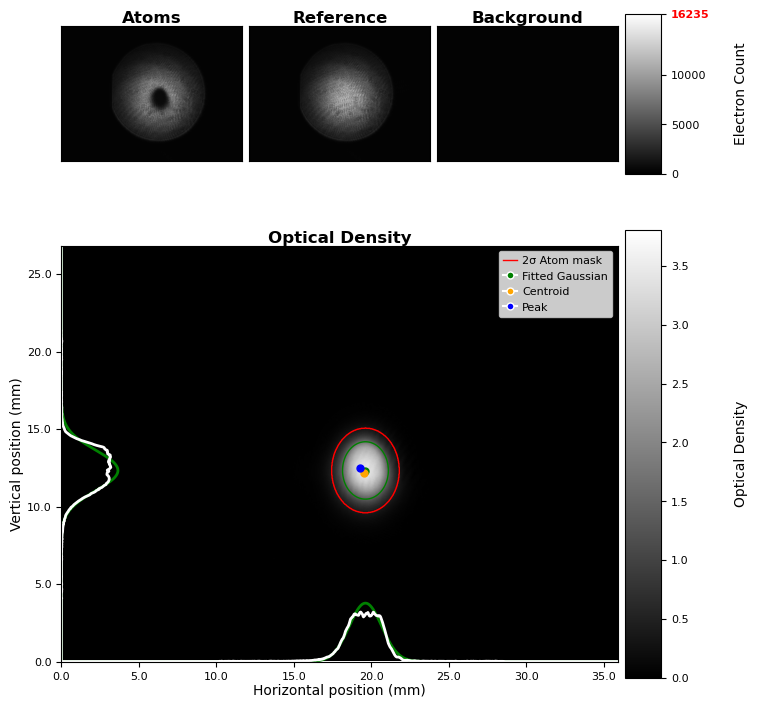

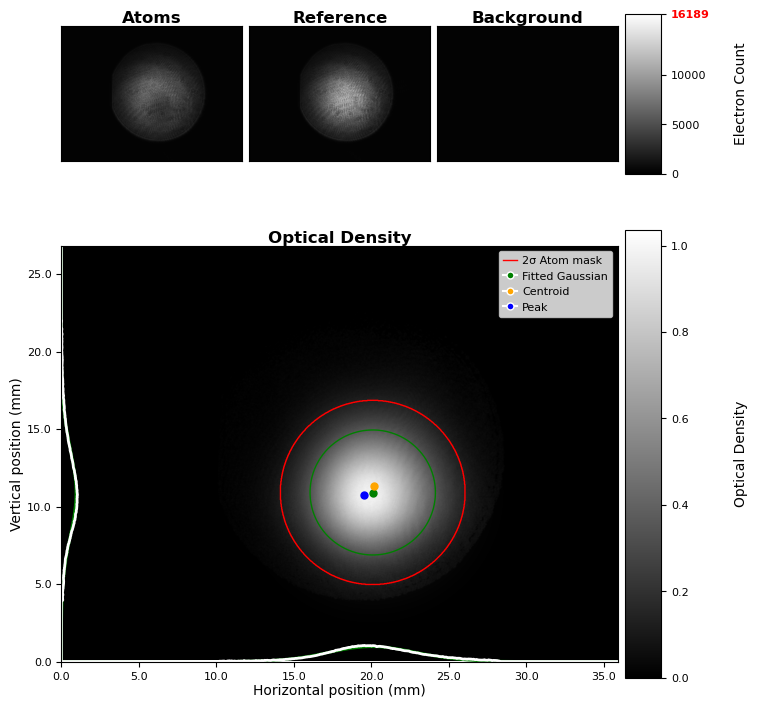

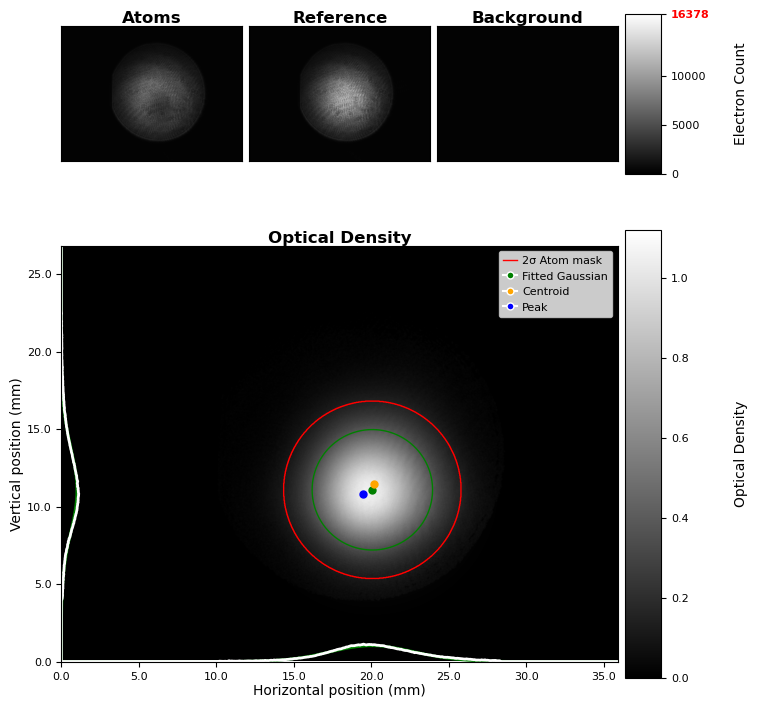

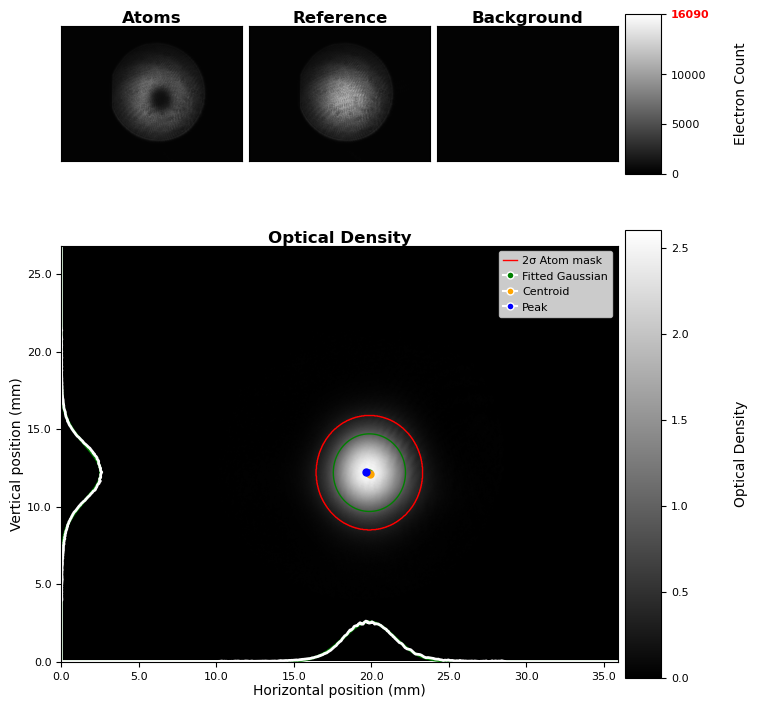

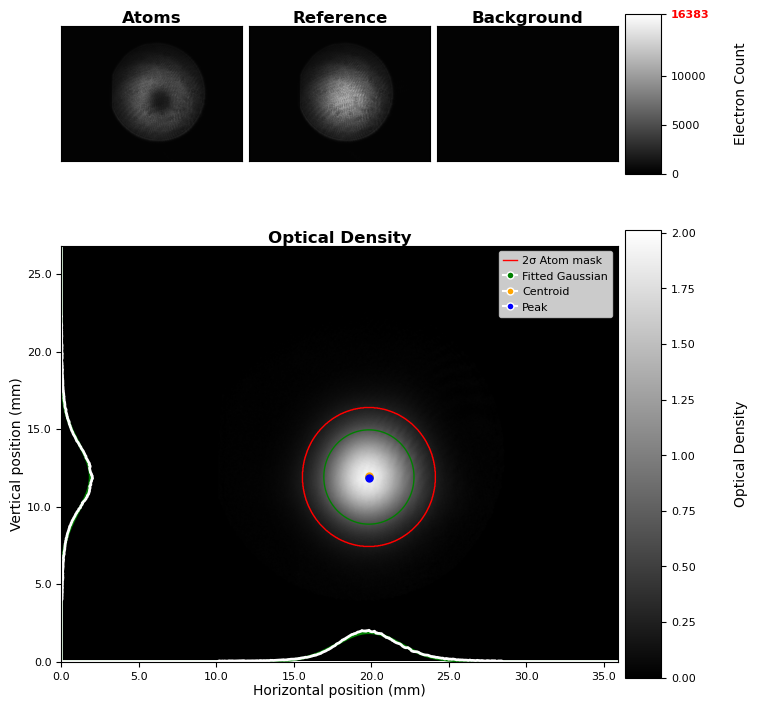

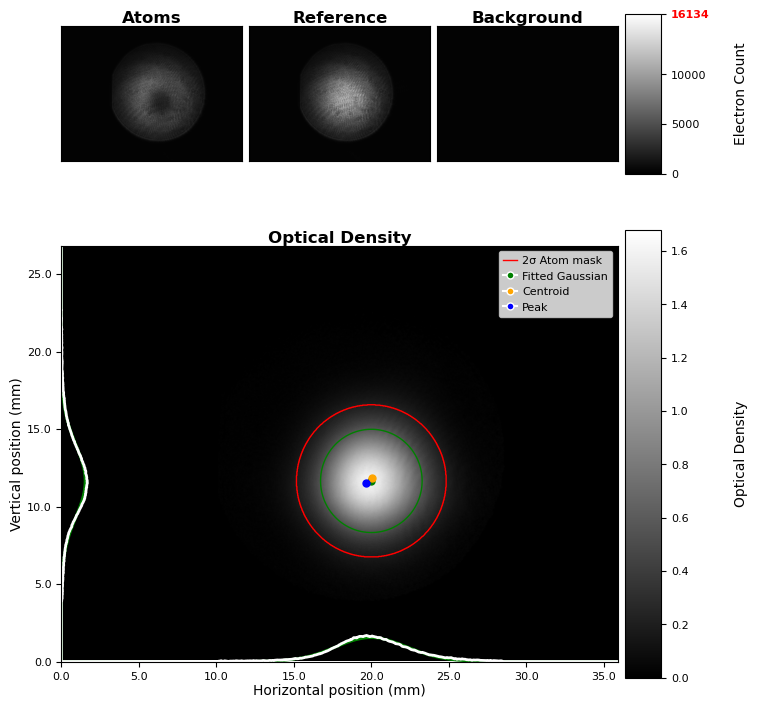

In [7]:
import h5py
from sipyco import pyon
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os as os
import sys
sys.path.append('/home/ae19663/artiq')  # Adjust this path to the parent directory of 'repository'
from repository.imaging.processor import AbsImage  # noqa: E402
import pandas as pd


# it will take folder(scan path) path as input and return sorted list of h5 files DIRECTORY
# the files are sorted based on the numeric part of their names, which is before the first hyphen '-'.
# For example, if the files are named like "000001234-AbsorptionImageExpFrag.h5",
# the sorting will be based on the numeric part "000001234".


folder_directory= "../results/2025-07-21/21/"  # Example directory path, adjust as needed
file_names = os.listdir(folder_directory)

# this will print the file names in the directory
print(f"Files in directory: {file_names}")


# Enter the name of the file you want to analyze, this file consisit of many runs of of particular scan parameter if you have multiple runs
particular_directory  = folder_directory+"000007639-AbsorptionImageExpFrag.h5"  # Example file path, adjust as needed

def sorted_files(directory):
    """
    Sort files in the given directory based on the numeric part of their names.
    """
    files = os.listdir(directory)
    file_num = []
    file_name = []

    for i in files:
        # Split the file name into two parts and sort by the numeric part
        file_num.append(i.split("-")[0])
        file_name.append(i.split("-")[1])

    # Sort the files based on the numeric part
    file_num, file_name = zip(*sorted(zip(file_num, file_name)))

    # Recombine the file number and file name into a single list
    sorted_files_list = [f"{num}-{name}" for num, name in zip(file_num, file_name)]

    # Directory list for the files using the sorted file names
    files_directory = [
        os.path.join(directory, f) for f in sorted_files_list if f.endswith(".h5")
    ]
    
    # Example usage:
    # directory = "../results/2025-07-08/21/"
    # files_directory = sorted_files(directory)

    return files_directory


def get_override_args(file_directory, hide_defaults=True):
    vals = {}

    f1 = h5py.File(file_directory, "r")
    args = pyon.decode(f1["expid"][()])["arguments"]
    for k, v in args.items():
        if k == "ndscan_params":
            params = pyon.decode(args["ndscan_params"])
            overrides = params["overrides"]
            for k, v in overrides.items():
                spec = params["schemata"][k]["spec"]
                val = v[0]["value"]
                default = type(val)(params["schemata"][k]["default"])
                if hide_defaults and val == default:
                    continue
                vals[k] = [val / spec.get("scale", 1), spec.get("unit", "")]
        else:
            vals[k] = [v, ""]
    return vals


vals = get_override_args(particular_directory, hide_defaults=False)


def args_names_and_vals(vals):
    # Print arguments names and their values
    args_names = []
    args_vals = []
    for k, (v, unit) in vals.items():
        # print(f"{k} = {v} {unit}")
        args_names.append(k)
        args_vals.append(v)
    return args_names, args_vals


files_directory = sorted_files(folder_directory)
# print(files_directory)

matching_args = []
for i in range(len(files_directory)):
    print(f"File {i + 1}: {files_directory[i]}")
    vals1 = get_override_args(files_directory[i])
    args_name1, args_val1 = args_names_and_vals(vals)
    for j in range(len(files_directory)):
        vals2 = get_override_args(files_directory[j])
        args_name2, args_val2 = args_names_and_vals(vals2)
        if args_name1 == args_name2:
            # print(f"Matching arguments found for {files_directory[i]} and {files_directory[j]}")
            matching_args.append((files_directory[i], files_directory[j]))
        else:
            # print(f"No matching arguments for {files_directory[i]} and {files_directory[j]}")
            pass


# plot the absorption image of the particular run in the scan, it is still a work in progress not working properly
def plot_absorption_image(file_directory, run_number):
    f1 = h5py.File(file_directory, "r")
    if run_number == 0:
        a = 0
    else:
        a = run_number * 3
    image_0 = "Images.All" + "." + str(a)
    image_1 = "Images.All" + "." + str(a + 1)
    image_2 = "Images.All" + "." + str(a + 2)

    absimg = AbsImage(
        data=f1["datasets"][image_0][()],
        ref=f1["datasets"][image_1][()],
        bg=f1["datasets"][image_2][()],
        magnification=0.25,  # Set default magnification
    )
    absimg.plot()
    plt.show()


scan_number = 1  # Example scan number, adjust as needed

plot_absorption_image(particular_directory, scan_number)
# Extracting the values and the units from the files
f1 = h5py.File(files_directory[0], "r")
a = f1["datasets"]

# calculate how many files are there in the directory
num_files = len(files_directory)
print(f"Number of files in the directory: {num_files}")


# extract all files images for scan parameter ranging from 0 to num_files fro 0 to 21
scan_param = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]

for i in scan_param:
    plot_absorption_image(particular_directory, i)
    

In [8]:
# example of the data structure in the file
all = [
"ndscan.rid_6597.analysis_results",
"ndscan.rid_6597.annotations",
"ndscan.rid_6597.axes",
"ndscan.rid_6597.channels",
"ndscan.rid_6597.completed",
"ndscan.rid_6597.fragment_fqn",
"ndscan.rid_6597.ndscan_schema_revision",
"ndscan.rid_6597.online_analyses",
"ndscan.rid_6597.points.axis_0",
"ndscan.rid_6597.points.channel_atom_number",
"ndscan.rid_6597.points.channel_info",
"ndscan.rid_6597.seed",
"ndscan.rid_6597.source_id",
]

# enter the file number you want to analyze
file_number = 14  # Example file number, adjust as needed

if file_number < 0 or file_number >= len(files_directory):
    raise ValueError(f"File number {file_number} is out of range. Please choose a number between 0 and {len(files_directory) - 1}.")    


# Extracting the values and the units from the files
f1 = h5py.File(files_directory[file_number], "r")
print(f1)
# extract file name and run number from the file path

file_name = os.path.basename(files_directory[file_number])
run_number = int(file_name.split("-")[0])
c="ndscan.rid_"+str(run_number)+".points.channel_info"
d="ndscan.rid_"+str(run_number)+".points.axis_1"


a= f1["datasets"][c][()]

peakx = []
peaky = []
centroidx = []
centroidy = []
wavelength = []
atom_number = []
A = []
sx = []
sy = []
x0 = []
y0 = []


import re

for i in range(a.shape[0]):
    # decode if bytes, otherwise use as is
    if isinstance(a[i], bytes):
        decoded = a[i].decode("utf-8")
        lines = decoded.split("\n")
       
    else:
        lines = a[i]

    for line in lines:
        b = line.strip(",").split(":")
        key = b[0].strip().strip('"')
        if key == "wavelength":
            wavelength.append(float(b[1]))
        elif key == "atom_number":
            atom_number.append(float(b[1]))
        elif key == "peak":  # Assuming this is a key for peak pixels
            # extract numbers from tuple string
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            if len(nums) >= 3:
                peakx.append(float(nums[0]))
                peaky.append(float(nums[1]))
                # If you want the third value, use float(nums[2])
            # else skip or handle error
        elif key == "centroid":  # Assuming this is a key for centroid pixels
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            if len(nums) >= 3:
                centroidx.append(float(nums[0]))
                centroidy.append(float(nums[1]))
                # If you want the third value, use float(nums[2])
        elif key == "best_values":  # Assuming this is a key for some values
            # Extract dictionary from line
            match = re.search(r"\{(.+?)\}", line)
            if match:
                dict_str = match.group(1)
                items = dict_str.split(",")
                for item in items:
                    item = item.strip()
                    if ":" in item:
                        key_part, value_part = item.split(":", 1)
                        key_item = key_part.strip().strip("'")
                        value_str = value_part.strip()
                        # Convert to float or int
                        if "." in value_str or "e" in value_str:
                            value = float(value_str)
                        else:
                            value = int(value_str)
                        # Append to the correct list
                        if key_item == "A":
                            A.append(value)
                        elif key_item == "x0":
                            x0.append(value)
                        elif key_item == "y0":
                            y0.append(value)
                        elif key_item == "sx":
                            sx.append(value)
                        elif key_item == "sy":
                            sy.append(value)
                        elif key_item == "theta":
                            if "theta" not in locals():
                                theta = []
                            theta.append(value)
                        elif key_item == "z0":
                            if "z0" not in locals():
                                z0 = []
                            z0.append(value)


# extract scan parameters from the file
scan_params = f1["datasets"][d][()]
print(scan_params)

# list contents in datasets
datasets = list(f1["datasets"].keys())
print("Datasets in the file:", datasets)


# print the extracted values
print("Wavelength:", wavelength)
print("Atom Number:", atom_number)
print("Peak X:", peakx)
print("Peak Y:", peaky)
print("Centroid X:", centroidx)
print("Centroid Y:", centroidy)
print("A:", A)
print("Sx:", sx)
print("Sy:", sy)
print("X0:", x0)
print("Y0:", y0)

# store everything in the csv file also scan parameters
data = {
    "wavelength": wavelength,
    "atom_number": atom_number,
    "peakx": peakx,
    "peaky": peaky,
    "centroidx": centroidx,
    "centroidy": centroidy,
    "A": A,
    "sx": sx,
    "sy": sy,
    "x0": x0,
    "y0": y0,
    "scan_params": scan_params,
}

# save file in this directory with directory name

output_directory = "/home/ae19663/Desktop/Deepak/analysis_files/" + file_name.split('.')[0] + "_run_" + str(run_number) + ".csv"
df = pd.DataFrame(data)
df.to_csv(output_directory, index=False)

<HDF5 file "000007639-AbsorptionImageExpFrag.h5" (mode r)>
[0.014 0.022 0.016 0.018 0.012 0.001 0.005 0.008 0.002 0.007 0.021 0.006
 0.009 0.017 0.011 0.003 0.004 0.02  0.019 0.01  0.013 0.015]
Datasets in the file: ['Images.All.0', 'Images.All.1', 'Images.All.10', 'Images.All.11', 'Images.All.12', 'Images.All.13', 'Images.All.14', 'Images.All.15', 'Images.All.16', 'Images.All.17', 'Images.All.18', 'Images.All.19', 'Images.All.2', 'Images.All.20', 'Images.All.21', 'Images.All.22', 'Images.All.23', 'Images.All.24', 'Images.All.25', 'Images.All.26', 'Images.All.27', 'Images.All.28', 'Images.All.29', 'Images.All.3', 'Images.All.30', 'Images.All.31', 'Images.All.32', 'Images.All.33', 'Images.All.34', 'Images.All.35', 'Images.All.36', 'Images.All.37', 'Images.All.38', 'Images.All.39', 'Images.All.4', 'Images.All.40', 'Images.All.41', 'Images.All.42', 'Images.All.43', 'Images.All.44', 'Images.All.45', 'Images.All.46', 'Images.All.47', 'Images.All.48', 'Images.All.49', 'Images.All.5', 'Images

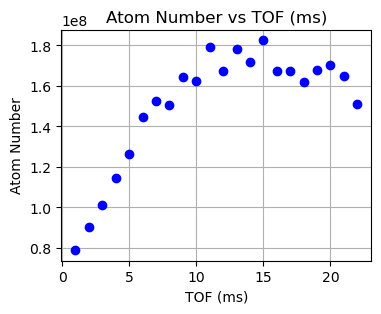

[0.014 0.022 0.016 0.018 0.012 0.001 0.005 0.008 0.002 0.007 0.021 0.006
 0.009 0.017 0.011 0.003 0.004 0.02  0.019 0.01  0.013 0.015]
[0.05112929 0.07045332 0.05722068 0.06333643 0.04571617 0.01869664
 0.02745575 0.03498477 0.02096562 0.03248941 0.0712182  0.03025166
 0.03804378 0.05971398 0.04428475 0.02316136 0.02531718 0.06923207
 0.0664954  0.03987057 0.04980501 0.05609604]


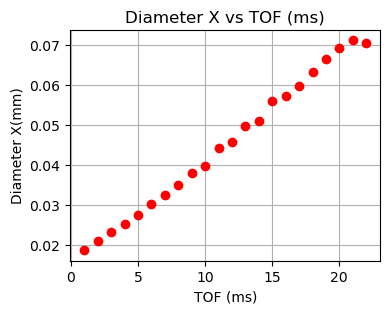

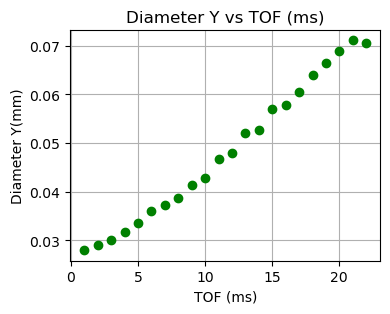

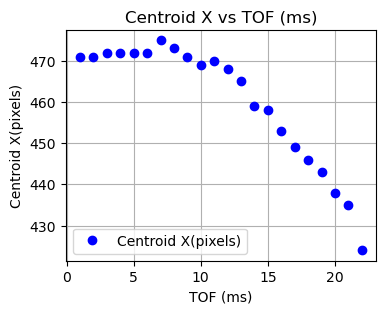

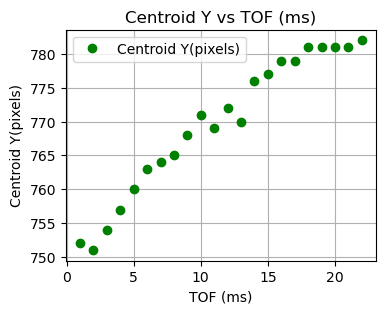

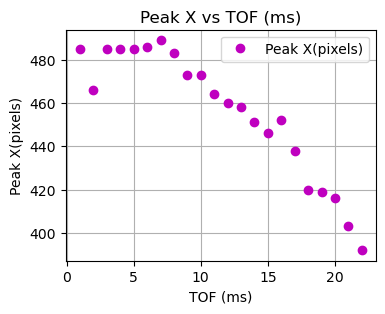

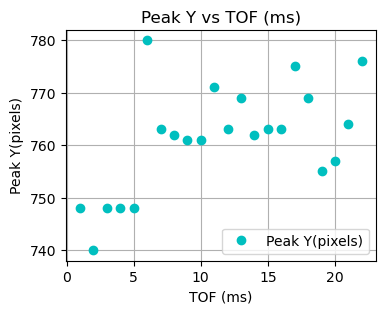

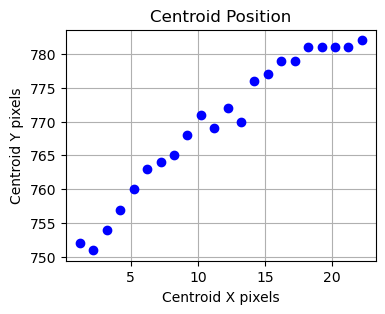

In [14]:
# exposure time
exposure_time=0.11e-3

scaling_factor = 25 * 1e-3

# add the exposure time to tof
scan_params = scan_params + exposure_time

sx = np.array(sx) * scaling_factor  # Convert to mm
sy = np.array(sy) * scaling_factor  # Convert to mm


# plot the atom number vs the scan parameter(TOF)
def plot_atom_number_vs_scan_param(atom_number, scan_param, d):
    """
    Plot atom number vs scan parameter from the given HDF5 file.
    """
    scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(scan_params * 1e3, atom_number, marker="o", linestyle="none", color="b")
    plt.xlabel(scan_param)
    plt.ylabel("Atom Number")
    plt.title("Atom Number vs " + scan_param)
    plt.grid()
    plt.show()


plot_atom_number_vs_scan_param(atom_number, "TOF (ms)", d)


# plot the diameterx vs the scan parameter(TOF)
def plot_diameterx_vs_scan_param(diameterx, scan_param, d):
    """
    Plot diameterx vs scan parameter from the given HDF5 file.
    """
    scan_params = f1["datasets"][d][()]
    print(scan_params)
    print(diameterx)
    plt.figure(figsize=(4, 3))
    plt.plot(scan_params * 1e3, diameterx, marker="o", linestyle="none", color="r")
    plt.xlabel(scan_param)
    plt.ylabel("Diameter X(mm)")
    plt.title("Diameter X vs " + scan_param)
    plt.grid()
    plt.show()


plot_diameterx_vs_scan_param(sx, "TOF (ms)", d)


def plot_diametery_vs_scan_param(diametery, scan_param, d):
    """
    Plot diametery vs scan parameter from the given HDF5 file.
    """
    scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(scan_params * 1e3, diametery, marker="o", linestyle="none", color="g")
    plt.xlabel(scan_param)
    plt.ylabel("Diameter Y(mm)")
    plt.title("Diameter Y vs " + scan_param)
    plt.grid()
    plt.show()


plot_diametery_vs_scan_param(sy, "TOF (ms)", d)


def plot_centroid_vs_scan_param(centroidx, scan_param, d):
    """
    Plot centroid vs scan parameter from the given HDF5 file.
    """
    scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(
        scan_params * 1e3,
        centroidx,
        marker="o",
        linestyle="none",
        color="b",
        label="Centroid X(pixels)",
    )
    plt.xlabel(scan_param)
    plt.ylabel("Centroid X(pixels)")
    plt.title("Centroid X vs " + scan_param)
    plt.legend()
    plt.grid()
    plt.show()


plot_centroid_vs_scan_param(centroidx, "TOF (ms)", d)


def plot_centroidy_vs_scan_param(centroidy, scan_param, d):
    """
    Plot centroidy vs scan parameter from the given HDF5 file.
    """
    scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(
        scan_params * 1e3,
        centroidy,
        marker="o",
        linestyle="none",
        color="g",
        label="Centroid Y(pixels)",
    )
    plt.xlabel(scan_param)
    plt.ylabel("Centroid Y(pixels)")
    plt.title("Centroid Y vs " + scan_param)
    plt.legend()
    plt.grid()
    plt.show()


plot_centroidy_vs_scan_param(centroidy, "TOF (ms)", d)


def plot_peak_vs_scan_param(peakx, scan_param, d):
    """
    Plot peak vs scan parameter from the given HDF5 file.
    """
    scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(
        scan_params * 1e3,
        peakx,
        marker="o",
        linestyle="none",
        color="m",
        label="Peak X(pixels)",
    )
    plt.xlabel(scan_param)
    plt.ylabel("Peak X(pixels)")
    plt.title("Peak X vs " + scan_param)
    plt.legend()
    plt.grid()
    plt.show()


plot_peak_vs_scan_param(peakx, "TOF (ms)", d)


def plot_peaky_vs_scan_param(peaky, scan_param, d):
    """
    Plot peaky vs scan parameter from the given HDF5 file.
    """
    scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(
        scan_params * 1e3,
        peaky,
        marker="o",
        linestyle="none",
        color="c",
        label="Peak Y(pixels)",
    )
    plt.xlabel(scan_param)
    plt.ylabel("Peak Y(pixels)")
    plt.title("Peak Y vs " + scan_param)
    plt.legend()
    plt.grid()
    plt.show()


plot_peaky_vs_scan_param(peaky, "TOF (ms)", d)


def plot_centroid_position(centroidx, centroidy, d):
    """
    Plot centroid position from the given HDF5 file.
    """
    plt.figure(figsize=(4, 3))
    plt.scatter(centroidx, centroidy, marker="o", color="b")
    plt.xlabel("Centroid X")
    plt.ylabel("Centroid Y")
    plt.title("Centroid Position")
    plt.grid()
    plt.show()


#make a plot function for general plotting with units specified
def plot_general(x, y, xlabel, ylabel, title, xunit='', yunit='', color='b', marker='o', linestyle='none'):
    """
    General plotting function.
    """
    plt.figure(figsize=(4, 3))
    plt.plot(x, y, marker=marker, linestyle=linestyle, color=color)
    plt.xlabel(xlabel + ' ' + xunit)
    plt.ylabel(ylabel + ' ' + yunit)
    plt.title(title)
    plt.grid()
    plt.show()


# plot centroid position
plot_general(scan_params * 1e3, centroidy, "Centroid X", "Centroid Y", "Centroid Position", xunit='pixels', yunit='pixels', color='b')

TOF data: [0.014 0.022 0.016 0.018 0.012 0.001 0.005 0.008 0.002 0.007 0.021 0.006
 0.009 0.017 0.011 0.003 0.004 0.02  0.019 0.01  0.013 0.015]
Diameter data: [5.26630171e-05 7.06595610e-05 5.77737279e-05 6.39468847e-05
 4.79983822e-05 2.79919823e-05 3.35018854e-05 3.86618599e-05
 2.89908416e-05 3.73359508e-05 7.11331349e-05 3.59666742e-05
 4.13833625e-05 6.04760391e-05 4.68048822e-05 3.01119218e-05
 3.16978453e-05 6.89997315e-05 6.64892851e-05 4.28569327e-05
 5.20520025e-05 5.70050091e-05]
Sorted TOF data: [0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011 0.012
 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022]
Sorted Diameter data: [2.79919823e-05 2.89908416e-05 3.01119218e-05 3.16978453e-05
 3.35018854e-05 3.59666742e-05 3.73359508e-05 3.86618599e-05
 4.13833625e-05 4.28569327e-05 4.68048822e-05 4.79983822e-05
 5.20520025e-05 5.26630171e-05 5.70050091e-05 5.77737279e-05
 6.04760391e-05 6.39468847e-05 6.64892851e-05 6.89997315e-05
 7.11331349e-05 7.065956

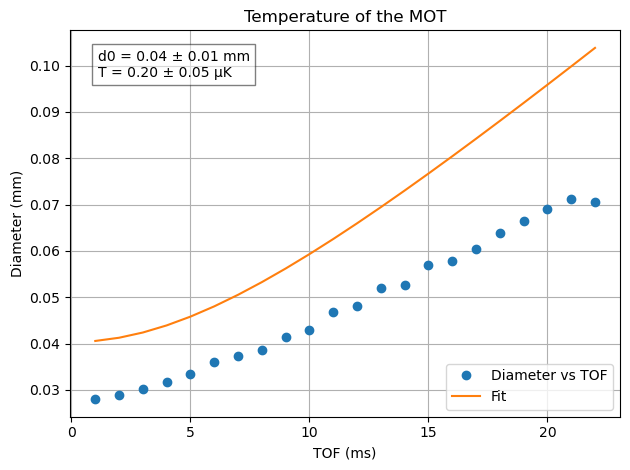

d0 = 0.040323479778851166 ± 0.008153825354032111 mm
T = 0.19865805527737446 ± 0.04611787685191451 μK


In [10]:
# curve fitting to find the diameter as a function of time of flight (TOF)
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# diameter scaling factor, taken from the applet py code
scaling_factor = 25 * 1e-6  # Example scaling factor, adjust as needed

t_data = f1["datasets"][d][()]  # TOF data
d_data = np.array(sy) * scaling_factor  # Diameter data, using sy as an example

print("TOF data:", t_data)
print("Diameter data:", d_data) 

# increasing order t data
t_data_sorted = np.sort(t_data)
print("Sorted TOF data:", t_data_sorted)


# return index of some value in t_data_sorted
def get_index_of_value(value, t_data_sorted):
    try:
        return np.where(t_data_sorted == value)[0][0]
    except IndexError:
        return -1

ind = get_index_of_value(t_data_sorted[0], t_data)

# diameter data sorted
d_data_sorted = d_data[np.argsort(t_data)]
print("Sorted Diameter data:", d_data_sorted)

# Boltzmann constant
kB = 1.380649e-23  # J/K
m = 1.45e-25  # kg


# http://ultracold.physi.uni-heidelberg.de/files/diplomarbeit-friedhelm.pdf

# Model: sqrt(d0^2 + (kB * T/m) * t^2)

def model(t, d0, T):
    return np.sqrt(d0**2 + (kB * T * t**2) / m)


# Fit your existing data
bounds = ([0, 0], [np.inf, np.inf])  # d0 and T must be positive
p0 = [30e-3, 200e-6]  # Initial guess
popt, pcov = curve_fit(model, t_data_sorted, d_data_sorted, p0=p0, bounds=bounds)
d0_fit, T_fit = popt
d0_err, T_err = np.sqrt(np.diag(pcov))

print(popt)

# Plot
plt.plot(t_data_sorted*1e3, d_data_sorted*1e3, "o", label="data")
plt.plot(t_data_sorted*1e3, model(t_data_sorted, *popt)*1e3, label="fit")
plt.xlabel("TOF (ms)")
plt.ylabel("Diameter (mm)")
plt.legend(["Diameter vs TOF", "Fit"])
plt.title("Temperature of the MOT")

# add fit results to the plot with box with proper formatting
fit_text = f"d0 = {d0_fit*1e3:.2f} ± {d0_err*1e3:.2f} mm\nT = {T_fit*1e6:.2f} ± {T_err*1e6:.2f} μK"
plt.gca().text(0.05, 0.95, fit_text, transform=plt.gca().transAxes,
               fontsize=10, verticalalignment='top',
               bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
plt.grid(True)
plt.tight_layout()
plt.show()

# Print results
print(f"d0 = {d0_fit*1e3} ± {d0_err*1e3} mm")
print(f"T = {T_fit*1e6} ± {T_err*1e6} μK")

Pixel data: [776. 782. 779. 781. 772. 752. 760. 765. 751. 764. 781. 763. 768. 779.
 769. 754. 757. 781. 781. 771. 770. 777.]
TOF data: [0.014 0.022 0.016 0.018 0.012 0.001 0.005 0.008 0.002 0.007 0.021 0.006
 0.009 0.017 0.011 0.003 0.004 0.02  0.019 0.01  0.013 0.015]
Sorted TOF data: [0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011 0.012
 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022]
Sorted Pixel data: [752. 751. 754. 757. 760. 763. 764. 765. 768. 771. 769. 772. 770. 776.
 777. 779. 779. 781. 781. 781. 781. 782.]
y0 = 759.2642548 ± 1.4351449 pixels
s = 81.2198081 ± 8.4364839 μm


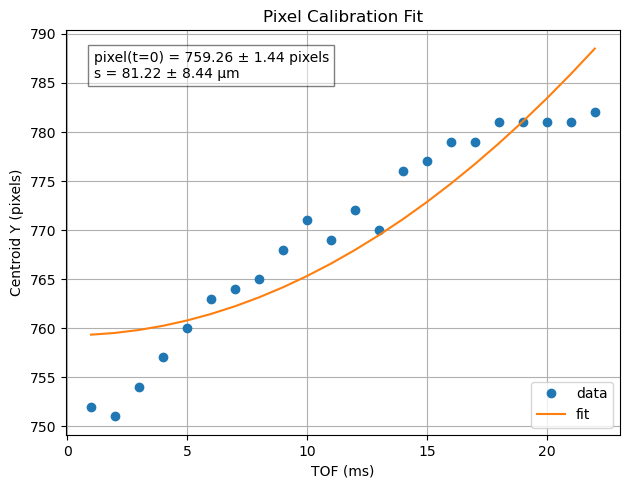

In [11]:
# pixel calibration fit
g=9.81  # m/s^2, gravitational acceleration

pixel_number_vertical_data = np.array(centroidy) # Pixel data, using sx as an example
print("Pixel data:", pixel_number_vertical_data)

print("TOF data:", t_data)

# increasing order t data
t_data_sorted = np.sort(t_data)
print("Sorted TOF data:", t_data_sorted)


# return index of some value in t_data_sorted
def get_index_of_value(value, t_data_sorted):
    try:
        return np.where(t_data_sorted == value)[0][0]
    except IndexError:
        return -1

# pixel data sorted
pixel_data_sorted = pixel_number_vertical_data[np.argsort(t_data)]
print("Sorted Pixel data:", pixel_data_sorted)


def model_pixel_calibration(t, y0, s):
    return y0 + (1/2) * t**2*g/s

# Initial GUESS
y0_initial = 750
s_initial = 40e-6

# Fit your existing data
popt_pixel, pcov_pixel = curve_fit(model_pixel_calibration, t_data_sorted, pixel_data_sorted, p0=[y0_initial, s_initial])
y0_fit = popt_pixel[0]
y0_err = np.sqrt(np.diag(pcov_pixel))[0]
s_fit = popt_pixel[1]
s_err = np.sqrt(np.diag(pcov_pixel))[1]

# Print results
print(f"y0 = {y0_fit:.7f} ± {y0_err:.7f} pixels")
print(f"s = {s_fit*1e6:.7f} ± {s_err*1e6:.7f} μm")


# Plot pixel calibration
plt.plot(t_data_sorted*1e3, pixel_data_sorted, "o", label="data")
plt.plot(t_data_sorted*1e3, model_pixel_calibration(t_data_sorted, *popt_pixel), label="fit")
plt.xlabel("TOF (ms)")
plt.ylabel("Centroid Y (pixels)")
plt.legend()
plt.grid(True)

fit_text = (
    f"pixel(t=0) = {y0_fit:.2f} ± {y0_err:.2f} pixels\ns = {s_fit*1e6:.2f} ±"
    f" {s_err*1e6:.2f} μm"
)
plt.gca().text(
    0.05,
    0.95,
    fit_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="black"),
)
plt.tight_layout()  
plt.title("Pixel Calibration Fit")
plt.show()

In [12]:
#give me list of numbers from 1 to 23 with spacing of 2
numbers_list = list(range(1, 24, 2))
print("List of numbers from 1 to 23 with spacing of 2:", numbers_list)

List of numbers from 1 to 23 with spacing of 2: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23]
